# Reconstructions Tomographiques : Radon, FBP et SART
Belgheir Imene - groupe 1

**Introduction**  
Ce notebook montre comment simuler l'acquisition tomographique d'une coupe (**le phantom de Shepp–Logan**), construire son **sinogramme** (transformée de Radon), puis reconstruire l'image à partir de ce sinogramme avec deux méthodes : **FBP (Filtered Back Projection)** et **SART (itératif)**. On calculera aussi des métriques (MSE, PSNR, SSIM) et on observera visuellement les différences.

Objectifs :
- Comprendre ce qu'est un sinogramme.
- Comparer FBP et SART en qualité et en défauts.
- Interpréter les métriques et les images d'erreur.


In [18]:
# Cellule: imports et configuration
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, metrics, img_as_float

# Pour affichage plus lisible dans le notebook
plt.rcParams['figure.figsize'] = (10, 8)


# 1) Chargement du phantom et préparation

Explication : on utilise le *Shepp–Logan phantom*, image synthétique couramment utilisée en tomographie.  
Nous convertissons en flottant et redimensionnons pour avoir une image carrée (ici 400×400).

Le phantom est un modèle simple mais réaliste pour tester des algorithmes CT.


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

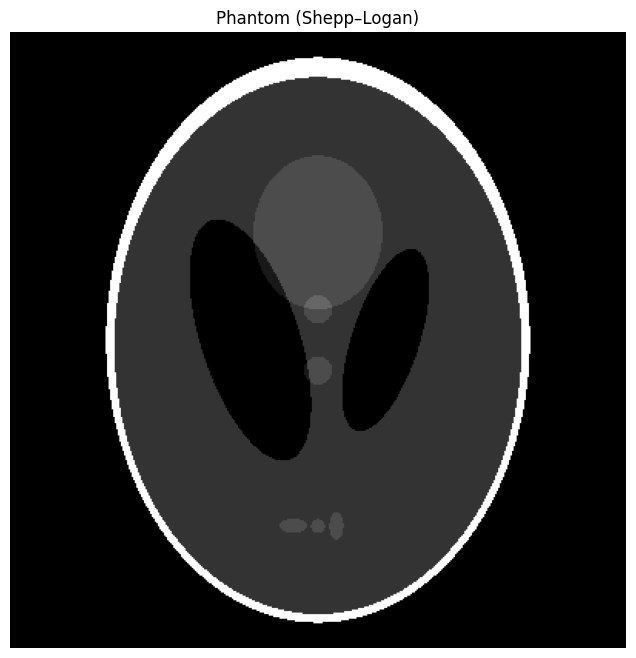

In [19]:
# Cellule: charger et préparer l'image (phantom)
phantom = img_as_float(data.shepp_logan_phantom())            # image en float dans [0,1]
phantom = transform.resize(phantom, (400, 400), anti_aliasing=True)
plt.imshow(phantom, cmap='gray')
plt.title("Phantom (Shepp–Logan)")
plt.axis('off')


# 2) Calcul du sinogramme (Radon)

**Qu'est-ce qu'on calcule ?**  
Le sinogramme est l'ensemble des projections (intensités mesurées) obtenues en faisant passer des rayons à travers l'objet pour différentes rotations.

**Fonction utilisée :** `skimage.transform.radon(image, theta=..., circle=...)`

- `image` : image 2D à transformer.
- `theta` : vecteur d'angles (en degrés) pour lesquels on calcule les projections. Exemple `np.linspace(0., 180., n_angles, endpoint=False)`.
- `circle` : booléen, si `True` on considère seulement le cercle inscrit dans l'image (utile pour éviter artefacts hors du disque).

**Paramètres importants :**
- `n_angles` : plus il est grand, meilleure la couverture angulaire → meilleure reconstruction FBP.
- La résolution verticale du sinogramme dépend de la taille de l'image.


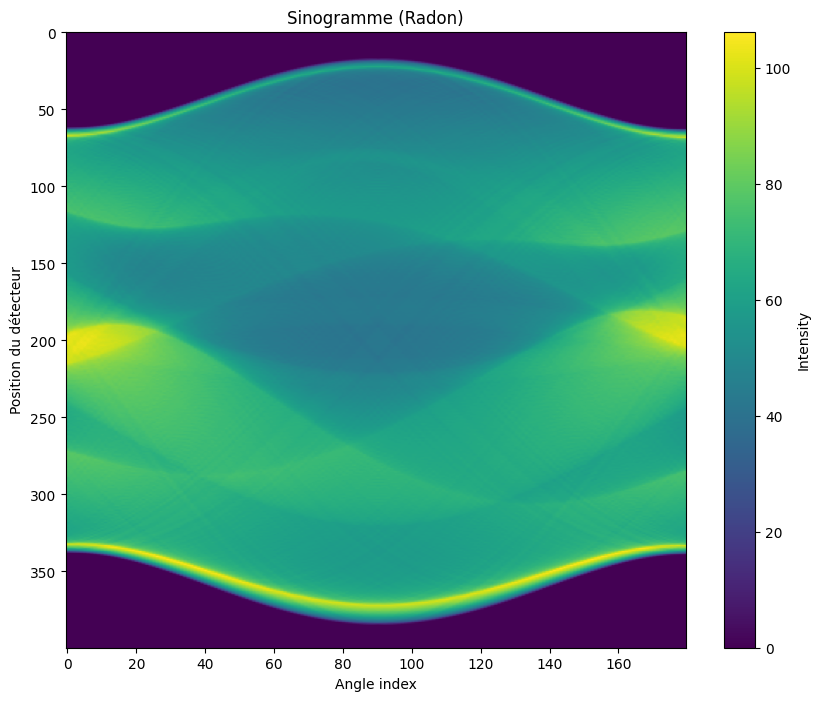

In [20]:
# Cellule: calculer sinogramme
n_angles = 180
theta = np.linspace(0., 180., n_angles, endpoint=False)
sinogram = transform.radon(phantom, theta=theta, circle=True)

plt.imshow(sinogram, aspect='auto')
plt.title("Sinogramme (Radon)")
plt.xlabel("Angle index")
plt.ylabel("Position du détecteur")
plt.colorbar(label='Intensity')


# Interprétation du sinogramme

- L'axe horizontal correspond aux angles (0 → 180°).  
- L'axe vertical correspond à la position le long du détecteur (déplacement perpendiculaire aux rayons).  
- Chaque point brillant dans l'objet crée une **courbe sinusoïdale** dans le sinogramme.  
- Le sinogramme contient toutes les données nécessaires pour reconstruire l'image.


# 3) Reconstruction par FBP (Filtered Back Projection)

**Principe** : Chaque projection est "reprojetée" (backprojected) dans l'image et on applique un filtrage en fréquence pour corriger le flou causé par la somme simple.

**Fonction utilisée :** `skimage.transform.iradon(sinogram, theta=..., filter_name='ramp', circle=True)`

Paramètres clés :
- `sinogram` : la matrice des projections.
- `theta` : mêmes angles que pour `radon`.
- `filter_name` : nom du filtre en domaine fréquence. Valeurs possibles : `'ramp'`, `'shepp-logan'`, `'cosine'`, `'hann'`, `'hamming'`, `'none'`...
  - `'ramp'` → amplifie hautes fréquences (meilleure netteté, plus de bruit).
  - fenêtrage (hann/hamming) → atténue bruit, lisse.
- `circle` : si True, reconstruction limitée au cercle inscrit.

**Observations attendues** :
- Très rapide.
- Si peu d'angles → apparition d'artefacts en rayons (streaks).
- Sensible au bruit : filtre choisi influence netteté vs bruit.


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

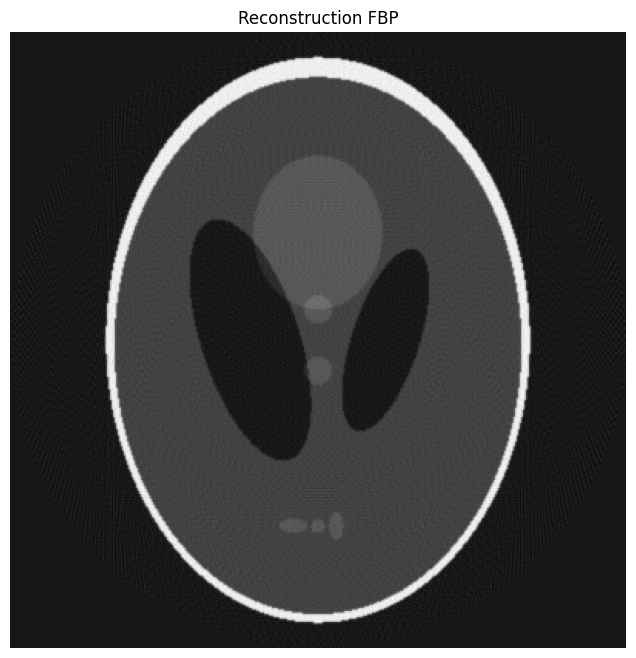

In [22]:
# Cellule: FBP reconstruction
recon_fbp = transform.iradon(sinogram, theta=theta, filter_name='ramp', circle=True)
plt.imshow(recon_fbp, cmap='gray')
plt.title("Reconstruction FBP")
plt.axis('off')


# 4) Reconstruction itérative : SART

**Idée** : commencer par une image initiale (zéro), simuler sa projection, comparer à la projection réelle, corriger l'image en redistribuant l'erreur le long des rayons. Répéter plusieurs fois.

**Fonction utilisée :** `skimage.transform.iradon_sart(sinogram, theta=..., image=None)`

Paramètres :
- `sinogram` : données mesurées.
- `theta` : angles.
- `image` : image initiale (si `None`, démarrage par défaut souvent une reconstruction coarse ou zéro).
- Dans l'implémentation scikit-image : la mise à jour se fait par **itérations successives** (on appelle la fonction plusieurs fois en passant l'image courante).

Paramètres "externes" importants à choisir dans la pratique :
- **Nombre d'itérations** : plus d'itérations → meilleure correspondance aux données, mais risque d'amplifier le bruit.
- **Relaxation / pas d'apprentissage** : parfois implémenté pour contrôler la magnitude des corrections (éviter overshoot). Dans `iradon_sart` de scikit-image, le contrôle est interne mais on répète manuellement plusieurs fois la fonction.

**Observations attendues** :
- Plus lent que FBP.
- Meilleure gestion des jeux de données incomplets (peu d'angles) et du bruit.
- Peut produire des résultats plus « propres » (moins de streaks) si réglé correctement.


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

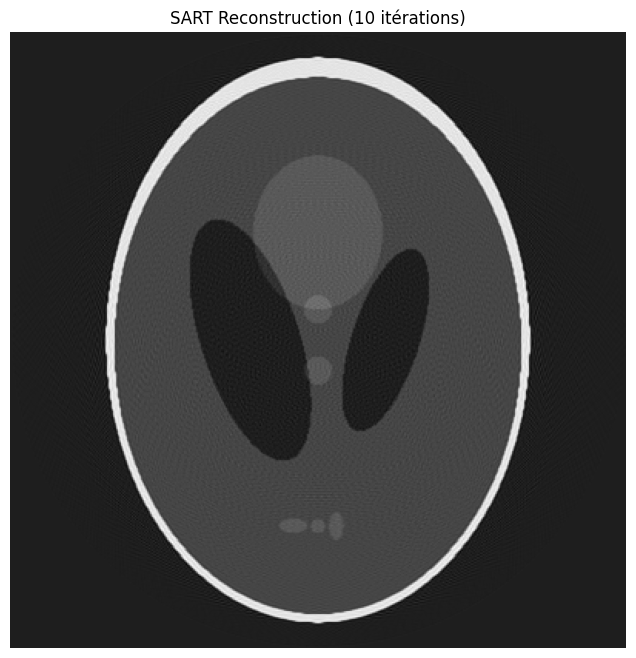

In [23]:
# Cellule: SART reconstruction (itérative)
recon_sart = transform.iradon_sart(sinogram, theta=theta)  # 1ère itération
n_iters = 9  # nombre d'itérations supplémentaires pour arriver à 10 iters
for i in range(n_iters):
    recon_sart = transform.iradon_sart(sinogram, theta=theta, image=recon_sart)

plt.imshow(recon_sart, cmap='gray')
plt.title(f"SART Reconstruction ({n_iters+1} itérations)")
plt.axis('off')


# 5) Préparation des images et calcul des métriques

**Métriques calculées :**
- **MSE (Mean Squared Error)** : moyenne des carrés des différences pixel à pixel. Plus petit = meilleur.
- **PSNR (Peak Signal to Noise Ratio)** : lié au MSE, exprimé en décibels (dB). Plus grand = meilleur.
- **SSIM (Structural Similarity Index)** : évalue la similarité perceptuelle (contraste, structure, luminance) entre deux images ; valeur dans [0,1]. Plus proche de 1 = meilleur.

**Fonctions utilisées :** `skimage.metrics.mean_squared_error`, `skimage.metrics.peak_signal_noise_ratio`, `skimage.metrics.structural_similarity`.

Remarque : On s'assure que toutes les images sont dans la même plage (ici [0,1]) et la même taille avant comparaison.


In [24]:
# Cellule: préparer images et calculer métriques
def prepare(img, ref_shape):
    img = np.clip(img, 0, 1)
    if img.shape != ref_shape:
        img = transform.resize(img, ref_shape, anti_aliasing=True)
    return img

orig = prepare(phantom, phantom.shape)
fbp = prepare(recon_fbp, phantom.shape)
sart = prepare(recon_sart, phantom.shape)

mse_fbp = metrics.mean_squared_error(orig, fbp)
mse_sart = metrics.mean_squared_error(orig, sart)

psnr_fbp = metrics.peak_signal_noise_ratio(orig, fbp, data_range=1.0)
psnr_sart = metrics.peak_signal_noise_ratio(orig, sart, data_range=1.0)

ssim_fbp = metrics.structural_similarity(orig, fbp, data_range=1.0)
ssim_sart = metrics.structural_similarity(orig, sart, data_range=1.0)

print("MSE  - FBP: {:.6f} , SART: {:.6f}".format(mse_fbp, mse_sart))
print("PSNR - FBP: {:.3f} dB , SART: {:.3f} dB".format(psnr_fbp, psnr_sart))
print("SSIM - FBP: {:.4f} , SART: {:.4f}".format(ssim_fbp, ssim_sart))


MSE  - FBP: 0.001079 , SART: 0.000808
PSNR - FBP: 29.672 dB , SART: 30.928 dB
SSIM - FBP: 0.7398 , SART: 0.8136


# Exemple de résultats (issus d'un run type)
- **MSE**  : FBP = *0.001079*, SART = *0.000808* (SART est plus petit → meilleur)
- **PSNR** : FBP = *29.7 dB*, SART = *30.9 dB* (plus grand = meilleur)
- **SSIM** : FBP = *0.7398*, SART = *0.8136* (SART plus proche de 1 → meilleur)

**Interprétation** : Dans cet exemple SART (après ~10 itérations) donne une reconstruction numériquement et visuellement meilleure que FBP : moins d'erreurs moyennes, meilleure similarité perceptuelle.


# 6) Visualisations finales

- Image originale (phantom)
- Sinogramme
- Reconstruction FBP
- Reconstruction SART (après N iters)
- Carte d'erreur (reconstruction - original) pour chaque méthode
- Zoom centre pour voir détails et bruit

Ces images aident à justifier les observations qualitatives (streaks, bruits, contour des objets).


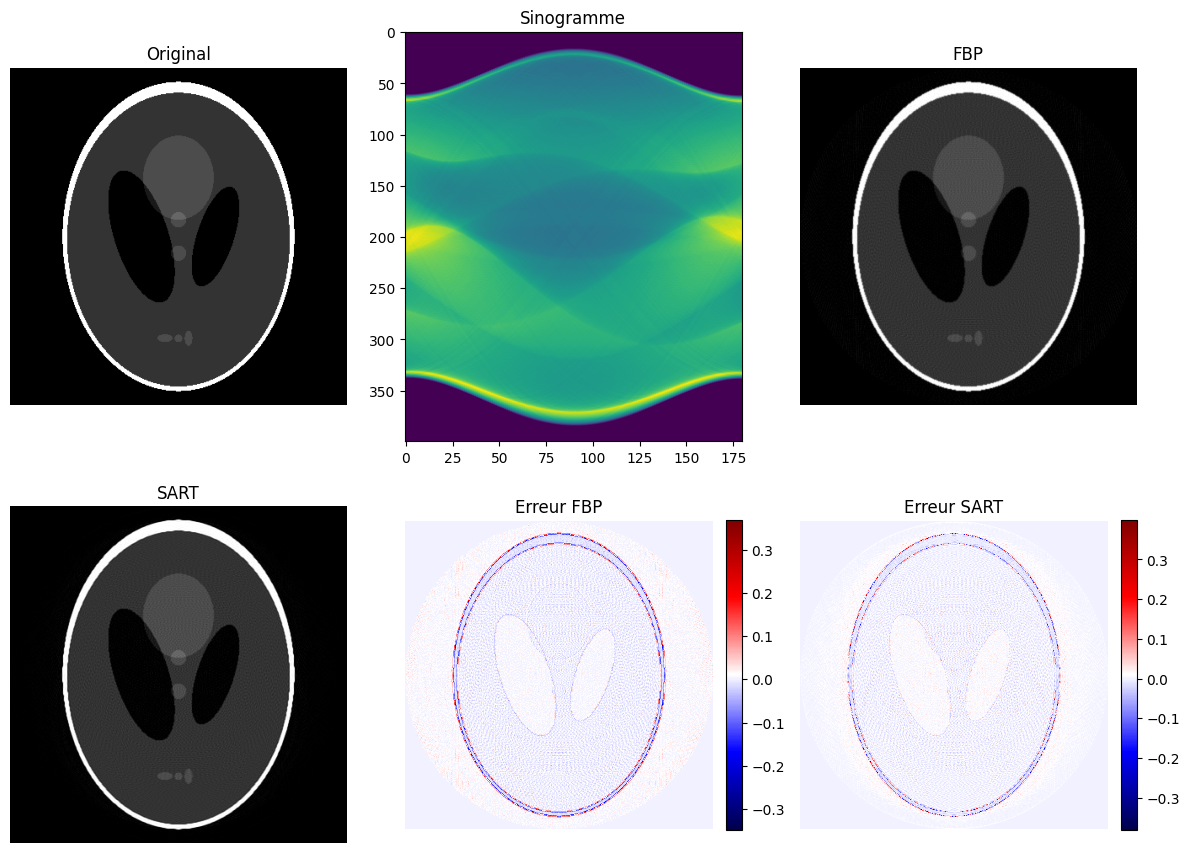

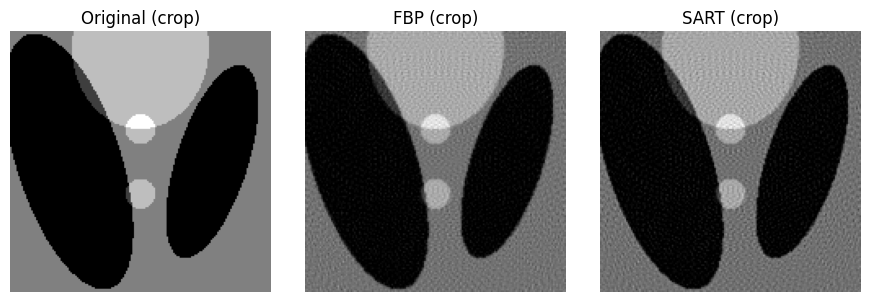

In [27]:
# Cellule: tracés finaux (original, sinogramme, FBP, SART, cartes d'erreur, crops)
plt.figure(figsize=(12,9))

plt.subplot(2,3,1); plt.imshow(orig, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(sinogram, aspect='auto'); plt.title("Sinogramme"); plt.axis('on')
plt.subplot(2,3,3); plt.imshow(fbp, cmap='gray'); plt.title("FBP"); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(sart, cmap='gray'); plt.title("SART"); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(fbp - orig, cmap='seismic'); plt.title("Erreur FBP"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(sart - orig, cmap='seismic'); plt.title("Erreur SART"); plt.colorbar(fraction=0.046, pad=0.04); plt.axis('off')

plt.tight_layout()
plt.show()

# Zoom crop center pour comparaison visuelle
h, w = orig.shape
c = 80
cx, cy = w//2, h//2
crop_orig = orig[cy-c:cy+c, cx-c:cx+c]
crop_fbp = fbp[cy-c:cy+c, cx-c:cx+c]
crop_sart = sart[cy-c:cy+c, cx-c:cx+c]

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); plt.imshow(crop_orig, cmap='gray'); plt.title("Original (crop)"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(crop_fbp, cmap='gray'); plt.title("FBP (crop)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(crop_sart, cmap='gray'); plt.title("SART (crop)"); plt.axis('off')
plt.tight_layout()
plt.show()


# questions fréquentes

- **Que montre le sinogramme ?**  
  Il montre comment chaque position sur le détecteur varie en fonction de l'angle. Des points dans l'image produisent des traces sinusoïdales dans le sinogramme.

- **Pourquoi FBP laisse-t-il des artefacts ?**  
  FBP repose sur une intégration directe des projections avec filtrage : si les angles manquent (sparse view) ou si le bruit est important, la somme des rétroprojections laisse apparaître des stries (streaks) et des artefacts de type rémanence fréquentielle.

- **Pourquoi SART peut mieux marcher ?**  
  SART ajuste l'image graduellement en minimisant l'écart entre projections simulées et réelles. Il peut exploiter la redondance et corriger localement, ce qui réduit les streaks quand les projections sont limitées ou bruitées.

- **Inconvénients de SART ?**  
  Coût computationnel (beaucoup d'itérations). Risque de sur-ajustement / amplification du bruit si on itère trop sans régularisation.

- **Effet du nombre d'angles** :  
  - Beaucoup d'angles → FBP fonctionne très bien, SART aussi mais moins nécessaire.  
  - Peu d'angles → SART souvent préférable.

- **Effet du nombre d'itérations SART** :  
  - Peu d'itérations → image floue / incomplète.  
  - Trop d'itérations → bruit amplifié. Trouver un compromis (p.ex. 10–20 iters selon problème).


# Conclusion

- Le sinogramme regroupe toutes les projections nécessaires à la reconstruction.  
- **FBP** est rapide et simple, adapté quand on a beaucoup de projections et peu de bruit.  
- **SART** est itératif, plus lent mais souvent plus robuste face au peu d'angles ou au bruit : il compare les projections simulées à celles mesurées et corrige progressivement l'image.  
- Dans l'exemple pratique du phantom, SART (après ~10 itérations) a montré une MSE plus faible, un PSNR plus élevé et un SSIM plus élevé que FBP, ce qui indique une meilleure qualité visuelle et numérique.  
